In [2]:
import pandas as pd

# Load the dataset to inspect its contents
file_path = '/Users/kashishgidwani/Documents/venv/python/carpooling_dataset.csv'
carpooling_data = pd.read_csv(file_path)

# Display the first few rows of the dataset
carpooling_data.head()


,trip_id,date,time,driver_id,start_location,end_location,distance,duration,petrol_price,vehicle_mileage,...,name_passenger_3,department_passenger_3,year_passenger_3,phone_passenger_3,email_passenger_3,address_passenger_3,has_car_passenger_3,preferred_role_passenger_3,schedule_flexibility_passenger_3,rating_passenger_3
0,739776,18-10-2024,05:13:00,13733153,College Campus,Porur,10.5,69,89.64,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,840211,06-03-2024,12:07:10,42041085,Porur,College Campus,6.2,87,86.08,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,349185,10-01-2024,10:25:40,54363070,College Campus,Porur,27.3,35,92.24,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,686975,01-09-2024,11:37:00,61327131,Adyar,College Campus,17.2,35,91.11,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,639235,26-07-2024,19:30:09,82493791,Velachery,College Campus,29.8,22,88.57,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Step 1: Filter dataset for students who have a car
# Checking for fields related to "has_car" to identify drivers.
drivers = carpooling_data[carpooling_data['has_car_passenger_1'] == 1]

# Step 2: Filter passengers without cars
passengers = carpooling_data[carpooling_data['has_car_passenger_1'] != 1]

# Step 3: Identify potential matches based on date, time, and location constraints.
# We'll group the data by location and time attributes for easier route matching.

# Simplifying the data to analyze start location, date, and time matches
drivers_relevant = drivers[['driver_id', 'start_location', 'end_location', 'date', 'time']]
passengers_relevant = passengers[['trip_id', 'start_location', 'end_location', 'date', 'time']]

# Merging passengers with drivers based on matching 'start_location', 'date', 'time'
# This step finds potential passengers who can be picked by each driver based on start location and time.
route_matches = drivers_relevant.merge(passengers_relevant,
                                       on=['start_location', 'date', 'time'],
                                       suffixes=('_driver', '_passenger'))

# Step 4: Limit passengers per driver to 3 per trip
# We group by each driver and take up to 3 passengers per trip

# Count and group by driver, limiting to maximum of 3 passengers
optimized_routes = route_matches.groupby('driver_id').head(3)

# Display the optimized routes
optimized_routes.head(10)


,driver_id,start_location,end_location_driver,date,time,trip_id,end_location_passenger


In [4]:
from datetime import timedelta

# Convert 'time' to datetime for time range flexibility
drivers_relevant['time'] = pd.to_datetime(drivers_relevant['time'], format='%H:%M:%S').dt.time
passengers_relevant['time'] = pd.to_datetime(passengers_relevant['time'], format='%H:%M:%S').dt.time

# Define a function to check if passenger time is within a specified range of driver time
def is_time_within_range(driver_time, passenger_time, time_range=15):
    """
    Check if passenger time is within the time range (in minutes) of driver time.
    """
    driver_time = pd.to_datetime(driver_time.strftime("%H:%M:%S"))
    passenger_time = pd.to_datetime(passenger_time.strftime("%H:%M:%S"))
    return abs((driver_time - passenger_time).total_seconds()) / 60 <= time_range

# Set a time flexibility window of 15 minutes
time_flexibility = 15

# List to store optimized routes
optimized_routes = []

# Check each driver and find matching passengers within time range and same/nearby locations
for _, driver in drivers_relevant.iterrows():
    # Filter passengers for the same date and within the time range
    possible_passengers = passengers_relevant[
        (passengers_relevant['date'] == driver['date']) &
        (passengers_relevant['start_location'] == driver['start_location'])
    ]

    # Further filter passengers within the time range flexibility
    matching_passengers = possible_passengers[
        possible_passengers['time'].apply(lambda x: is_time_within_range(driver['time'], x, time_flexibility))
    ]

    # Select up to 3 passengers for this driver
    selected_passengers = matching_passengers.head(3)

    # Append matches to the optimized routes list
    for _, passenger in selected_passengers.iterrows():
        optimized_routes.append({
            'driver_id': driver['driver_id'],
            'driver_location': driver['start_location'],
            'passenger_trip_id': passenger['trip_id'],
            'passenger_location': passenger['start_location'],
            'date': driver['date'],
            'time': driver['time']
        })

# Convert optimized routes to DataFrame for analysis
optimized_routes_df = pd.DataFrame(optimized_routes)

# Display the optimized routes
optimized_routes_df.head(10)


/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/2489671063.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers_relevant['time'] = pd.to_datetime(drivers_relevant['time'], format='%H:%M:%S').dt.time
/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/2489671063.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passengers_relevant['time'] = pd.to_datetime(passengers_relevant['time'], format='%H:%M:%S').dt.time


,driver_id,driver_location,passenger_trip_id,passenger_location,date,time
0,78060456,College Campus,77405,College Campus,21-12-2024,17:15:52
1,4182471,College Campus,411703,College Campus,12-03-2024,06:33:54
2,44830139,College Campus,957893,College Campus,07-10-2024,11:39:51
3,10327139,College Campus,86198,College Campus,23-07-2024,10:22:38
4,83649499,Mylapore,787293,Mylapore,26-01-2024,15:23:53
5,52057659,College Campus,899241,College Campus,20-01-2024,05:34:34
6,52057659,College Campus,360156,College Campus,20-01-2024,05:34:34
7,25595932,College Campus,737057,College Campus,11-10-2024,23:56:39
8,42944315,College Campus,602130,College Campus,13-02-2024,16:49:20
9,29218857,College Campus,607035,College Campus,11-06-2024,04:52:40


In [5]:
# **Assign a value to driver_location**
driver_location = "Mylapore"  # Replace with the desired driver location

# Filter the dataframe to get rows where the driver and students locations match.
student_names_in_location = optimized_routes_df[optimized_routes_df["passenger_location"] == driver_location]

# Or you can print the dataframe for all relevant data:
student_names_in_location

,driver_id,driver_location,passenger_trip_id,passenger_location,date,time
4,83649499,Mylapore,787293,Mylapore,26-01-2024,15:23:53
44,48020105,Mylapore,155560,Mylapore,06-09-2024,06:42:59
67,71325726,Mylapore,601178,Mylapore,19-08-2024,18:39:17
109,86727720,Mylapore,988331,Mylapore,13-10-2024,21:40:32
121,20838055,Mylapore,820415,Mylapore,26-09-2024,04:00:15
152,83374564,Mylapore,298727,Mylapore,29-02-2024,03:26:08
265,22767702,Mylapore,335064,Mylapore,30-12-2024,22:38:09
308,89485665,Mylapore,523528,Mylapore,20-06-2024,04:23:53
318,34717861,Mylapore,650714,Mylapore,05-04-2024,18:12:55
321,50961876,Mylapore,254097,Mylapore,15-09-2024,12:21:32


In [6]:
# Filter drivers (students who have cars)
drivers = carpooling_data[carpooling_data['has_car_passenger_1'] == 1]
# Filter passengers (students without cars)
passengers = carpooling_data[carpooling_data['has_car_passenger_1'] != 1]

# Relevant columns for analysis
drivers = drivers[['driver_id', 'start_location', 'end_location', 'date', 'time', 'name_passenger_1']]
passengers = passengers[['trip_id', 'start_location', 'end_location', 'date', 'time', 'name_passenger_1']]

# Convert 'time' columns to datetime format for flexibility
drivers['time'] = pd.to_datetime(drivers['time'], format='%H:%M:%S').dt.time
passengers['time'] = pd.to_datetime(passengers['time'], format='%H:%M:%S').dt.time

# Function to check if times are within a certain range (15 min flexibility)
def is_time_within_range(driver_time, passenger_time, time_range=15):
    driver_time = pd.to_datetime(driver_time.strftime("%H:%M:%S"))
    passenger_time = pd.to_datetime(passenger_time.strftime("%H:%M:%S"))
    return abs((driver_time - passenger_time).total_seconds()) / 60 <= time_range

# Time flexibility in minutes
time_flexibility = 15
optimized_routes_with_names = []

# Find matches based on location, date, and time flexibility
for _, driver in drivers.iterrows():
    # Filter passengers by same location and date
    possible_passengers = passengers[
        (passengers['start_location'] == driver['start_location']) &
        (passengers['date'] == driver['date'])
    ]

    # Further filter passengers based on time flexibility
    matching_passengers = possible_passengers[
        possible_passengers['time'].apply(lambda x: is_time_within_range(driver['time'], x, time_flexibility))
    ]

    # Select up to 3 matching passengers
    selected_passengers = matching_passengers.head(3)

    # Append driver and passenger info
    for _, passenger in selected_passengers.iterrows():
        optimized_routes_with_names.append({
            'driver_id': driver['driver_id'],
            'driver_name': driver['name_passenger_1'],
            'driver_location': driver['start_location'],
            'passenger_name': passenger['name_passenger_1'],
            'passenger_trip_id': passenger['trip_id'],
            'passenger_location': passenger['start_location'],
            'date': driver['date'],
            'time': driver['time']
        })

# Convert to DataFrame
optimized_routes_with_names_df = pd.DataFrame(optimized_routes_with_names)

# Display the optimized routes
print(optimized_routes_with_names_df.head(10))


   driver_id     driver_name driver_location      passenger_name  \
0   78060456      Kiaan Gala  College Campus         Tiya Sunder   
1    4182471     Raunak Bedi  College Campus       Hansh Solanki   
2   44830139     Nehmat Devi  College Campus  Mishti Ranganathan   
3   10327139   Shlok Maharaj  College Campus        Jhanvi Hayer   
4   83649499  Yasmin Krishna        Mylapore     Nitara Bhargava   
5   52057659  Raunak Kothari  College Campus         Diya Ramesh   
6   52057659  Raunak Kothari  College Campus         Oorja Edwin   
7   25595932  Adira Deshmukh  College Campus         Anay Sarraf   
8   42944315        Ela Anne  College Campus    Lavanya Kulkarni   
9   29218857   Jayesh Gandhi  College Campus          Kanav Vasa   

   passenger_trip_id passenger_location        date      time  
0              77405     College Campus  21-12-2024  17:15:52  
1             411703     College Campus  12-03-2024  06:33:54  
2             957893     College Campus  07-10-2024  11:39:

In [9]:
import pandas as pd

# Load carpool and petrol prices datasets
carpooling_data = pd.read_csv('/Users/kashishgidwani/Documents/venv/python/carpooling_dataset.csv')
petrol_prices_data = pd.read_csv('/Users/kashishgidwani/Downloads/daily_petrol_prices.csv')

In [10]:
petrol_prices_data['Date'] = pd.to_datetime(petrol_prices_data['Date'], format='%d-%m-%Y', errors='coerce')

In [11]:
# Convert 'date' column to datetime in both DataFrames before merging
optimized_routes_with_names_df['Date'] = pd.to_datetime(optimized_routes_with_names_df['date'])
petrol_prices_data['Date'] = pd.to_datetime(petrol_prices_data['Date'])  # Assuming 'Date' is the date column in petrol_prices_data


# Now you can perform the merge
optimized_routes_with_names_df = pd.merge(optimized_routes_with_names_df,
                                         petrol_prices_data,
                                         on='Date',
                                         how='left')

/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/985979610.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  optimized_routes_with_names_df['Date'] = pd.to_datetime(optimized_routes_with_names_df['date'])


In [12]:
# Assuming you have a DataFrame 'optimized_routes_with_names_df' with driver and passenger information
# and a DataFrame 'petrol_prices_data' with daily petrol prices.

# Let's calculate the cost of petrol based on distance, mileage, and petrol price per day.
# We'll add columns for distance traveled, total cost, and cost per person to the DataFrame.

# Add a column for distance, assume this distance is between start and end locations
# Replace with actual distance calculation if you have lat/long or predefined distances.
optimized_routes_with_names_df['distance_km'] = 10  # Replace with actual distance

# Assume an average mileage of the car is 15 km/litre
average_mileage_kmpl = 15

# Calculate the total liters of petrol needed
optimized_routes_with_names_df['total_liters'] = optimized_routes_with_names_df['distance_km'] / average_mileage_kmpl

# **Change 1: Renaming the Price Column in petrol_prices_data before merging**
petrol_prices_data = petrol_prices_data.rename(columns={'Price': 'petrol_price'})

# Merge the carpooling dataset with the daily petrol price dataset based on the date.
# This will add the petrol price to the dataset for each carpooling trip.
optimized_routes_with_names_df = pd.merge(optimized_routes_with_names_df,
                                         petrol_prices_data[['Date', 'petrol_price']], # Select only the required columns
                                         on='Date',
                                         how='left')

# Calculate the total cost of petrol per trip
optimized_routes_with_names_df['total_petrol_cost'] = optimized_routes_with_names_df['total_liters'] * optimized_routes_with_names_df['petrol_price']

# Calculate the cost per person including the driver.
# This can be refined based on the number of passengers and driver's contribution preferences
optimized_routes_with_names_df['cost_per_person'] = optimized_routes_with_names_df['total_petrol_cost'] / 4  # Assuming 3 passengers and 1 driver

# Now, the 'optimized_routes_with_names_df' DataFrame contains the cost per person
# for each carpooling trip based on distance, mileage, and petrol price.


# Print the updated DataFrame to see the results
print(optimized_routes_with_names_df.head(10))

   driver_id     driver_name driver_location      passenger_name  \
0   78060456      Kiaan Gala  College Campus         Tiya Sunder   
1    4182471     Raunak Bedi  College Campus       Hansh Solanki   
2   44830139     Nehmat Devi  College Campus  Mishti Ranganathan   
3   10327139   Shlok Maharaj  College Campus        Jhanvi Hayer   
4   83649499  Yasmin Krishna        Mylapore     Nitara Bhargava   
5   52057659  Raunak Kothari  College Campus         Diya Ramesh   
6   52057659  Raunak Kothari  College Campus         Oorja Edwin   
7   25595932  Adira Deshmukh  College Campus         Anay Sarraf   
8   42944315        Ela Anne  College Campus    Lavanya Kulkarni   
9   29218857   Jayesh Gandhi  College Campus          Kanav Vasa   

   passenger_trip_id passenger_location        date      time       Date  \
0              77405     College Campus  21-12-2024  17:15:52 2024-12-21   
1             411703     College Campus  12-03-2024  06:33:54 2024-03-12   
2             957893   

In [13]:
# Assuming 'optimized_routes_with_names_df' is your DataFrame

for index, row in optimized_routes_with_names_df.iterrows():
    petrol_price = row['petrol_price']  # price per liter on that date

In [14]:
petrol_price = row['petrol_price']  # price per liter on that date

used K-means clustering

In [15]:
# prompt: using Clustering with K-Means
# Group passengers and drivers based on location and time proximity.

from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Assuming 'optimized_routes_with_names_df' is your DataFrame with driver and passenger information

# Create a new DataFrame with relevant features for clustering
clustering_data = optimized_routes_with_names_df[['driver_location', 'date', 'time']].copy()

# Convert 'date' and 'time' to numerical representation for clustering
clustering_data['date'] = pd.to_datetime(clustering_data['date']).astype(np.int64) // 10**9
clustering_data['time'] = pd.to_datetime(clustering_data['time'], format='%H:%M:%S').astype(np.int64) // 10**9

# Perform K-Means clustering
kmeans = KMeans(n_clusters=5)  # Choose the number of clusters (you can experiment with this)
kmeans.fit(clustering_data[['date', 'time']])  # Fit the model to the relevant features
cluster_labels = kmeans.labels_

# Add cluster labels to the original DataFrame
optimized_routes_with_names_df['cluster_label'] = cluster_labels

# Now, you can analyze groups of passengers and drivers based on the cluster labels
# For example, you can find all passengers and drivers in a specific cluster:
cluster_0_data = optimized_routes_with_names_df[optimized_routes_with_names_df['cluster_label'] == 0]
print(cluster_0_data.head())

# You can further analyze these clusters to understand the characteristics of each group
# and explore possible carpooling optimization strategies within those clusters.


    driver_id        driver_name driver_location      passenger_name  \
2    44830139        Nehmat Devi  College Campus  Mishti Ranganathan   
7    25595932     Adira Deshmukh  College Campus         Anay Sarraf   
11   55109971       Arhaan Verma  College Campus         Ojas Barman   
14   37775074  Riya Ramakrishnan  College Campus  Mishti Ranganathan   
21    4866365          Diya Rana  College Campus     Khushi Sankaran   

    passenger_trip_id passenger_location        date      time       Date  \
2              957893     College Campus  07-10-2024  11:39:51 2024-10-07   
7              737057     College Campus  11-10-2024  23:56:39 2024-10-11   
11             336678     College Campus  25-10-2024  00:32:31 2024-10-25   
14             820720     College Campus  30-08-2024  21:16:27 2024-08-30   
21             361606     College Campus  30-10-2024  16:54:07 2024-10-30   

    Price  distance_km  total_liters  petrol_price  total_petrol_cost  \
2   89.35           10      0.6

/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/4290412220.py:14: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  clustering_data['date'] = pd.to_datetime(clustering_data['date']).astype(np.int64) // 10**9


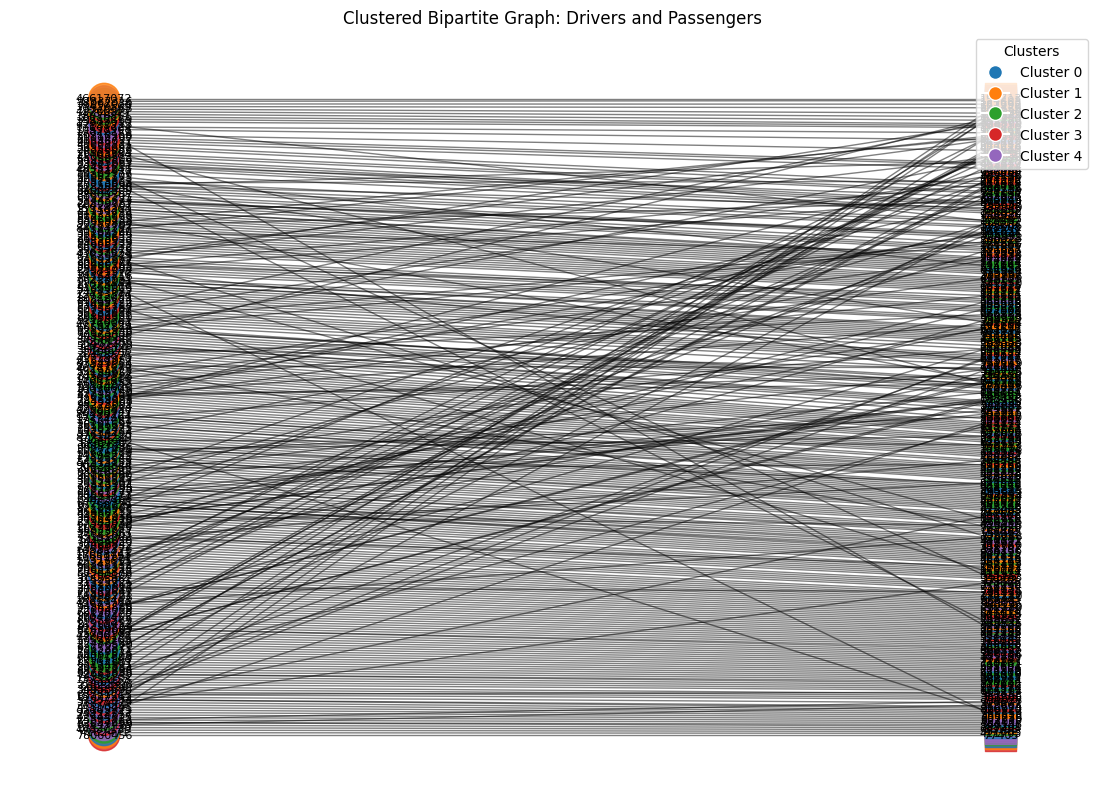

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a bipartite graph for drivers and passengers
bipartite_graph = nx.Graph()

# Separate driver and passenger nodes with cluster labels
driver_nodes = []
passenger_nodes = []
edges = []

for _, row in optimized_routes_with_names_df.iterrows():
    driver = row['driver_id']
    passenger = row['passenger_trip_id']
    cluster = row['cluster_label']

    driver_nodes.append((driver, {'cluster': cluster, 'type': 'driver'}))
    passenger_nodes.append((passenger, {'cluster': cluster, 'type': 'passenger'}))
    edges.append((driver, passenger))

# Add nodes and edges to the graph
bipartite_graph.add_nodes_from(driver_nodes)
bipartite_graph.add_nodes_from(passenger_nodes)
bipartite_graph.add_edges_from(edges)

# Create a color map for clusters
unique_clusters = list(set(nx.get_node_attributes(bipartite_graph, 'cluster').values()))
colors = plt.cm.tab10(range(len(unique_clusters)))
cluster_color_map = dict(zip(unique_clusters, colors))

# Assign colors to nodes based on their cluster
node_colors = [cluster_color_map[data['cluster']] for _, data in bipartite_graph.nodes(data=True)]
node_shapes = ['o' if data['type'] == 'driver' else 's' for _, data in bipartite_graph.nodes(data=True)]

# Draw bipartite graph
plt.figure(figsize=(14, 10))
pos = nx.drawing.layout.bipartite_layout(bipartite_graph, [n for n, d in bipartite_graph.nodes(data=True) if d['type'] == 'driver'])
for shape in set(node_shapes):
    shape_nodes = [n for n, s in zip(bipartite_graph.nodes(), node_shapes) if s == shape]
    nx.draw_networkx_nodes(bipartite_graph, pos, nodelist=shape_nodes,
                           node_color=[cluster_color_map[bipartite_graph.nodes[n]['cluster']] for n in shape_nodes],
                           node_shape=shape, node_size=500, alpha=0.8)
nx.draw_networkx_edges(bipartite_graph, pos, alpha=0.5)
nx.draw_networkx_labels(bipartite_graph, pos, font_size=8)

# Create legend for clusters
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}', markerfacecolor=cluster_color_map[c], markersize=10)
    for c in unique_clusters
]
plt.legend(handles=legend_elements, loc='upper right', title='Clusters')

plt.title('Clustered Bipartite Graph: Drivers and Passengers')
plt.axis('off')
plt.show()


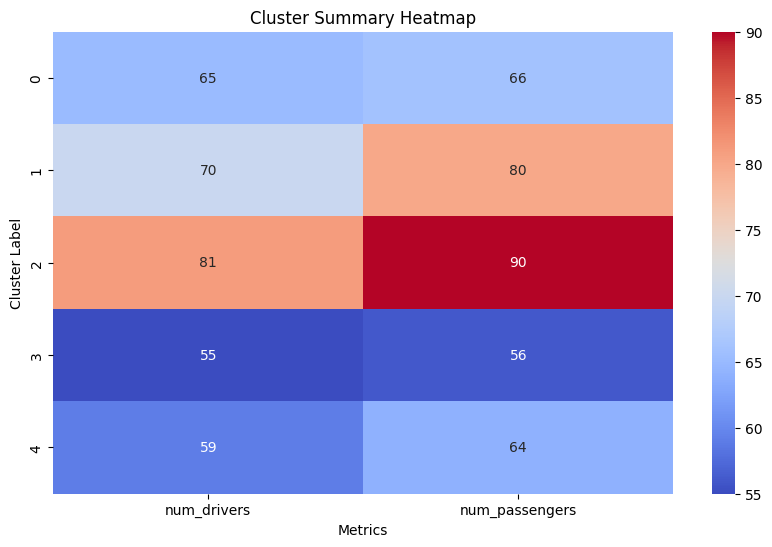

In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Create a summary DataFrame
cluster_summary = optimized_routes_with_names_df.groupby('cluster_label').agg(
    num_drivers=('driver_id', 'nunique'),
    num_passengers=('passenger_trip_id', 'nunique')
).reset_index()

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary.set_index('cluster_label'), annot=True, cmap='coolwarm', fmt="d")
plt.title('Cluster Summary Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Cluster Label')
plt.show()


In [18]:
from sklearn.metrics import silhouette_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Prepare data for silhouette score calculation
X = optimized_routes_with_names_df[['date', 'time']].copy()

# Convert 'date' and 'time' to numeric
X['date'] = pd.to_numeric(X['date'], errors='coerce')
X['time'] = pd.to_numeric(X['time'], errors='coerce')

# Remove rows with NaN values resulting from conversion errors
X = X.dropna()

# Update labels to reflect the rows kept in X after removing NaNs
labels = optimized_routes_with_names_df.loc[X.index, 'cluster_label']

# Validate that there are enough samples and clusters
if X.shape[0] < 2 or len(set(labels)) < 2:
    print("Not enough samples or clusters to compute silhouette score.")
else:
    # Calculate silhouette score
    silhouette_avg = silhouette_score(X, labels)
    print("Silhouette Score:", silhouette_avg)

# Classification Report
# Assuming 'driver_location' is the target variable
target_variable = 'driver_location'

# Ensure the target variable exists and has valid data
if target_variable in optimized_routes_with_names_df.columns:
    # Encode the target variable into numerical values
    le = LabelEncoder()
    optimized_routes_with_names_df[target_variable] = le.fit_transform(optimized_routes_with_names_df[target_variable])

    # Extract true labels and predicted labels
    true_labels = optimized_routes_with_names_df[target_variable]
    predicted_labels = optimized_routes_with_names_df['cluster_label']

    # Generate the classification report
    try:
        report = classification_report(true_labels, predicted_labels)
        print("Classification Report:\n", report)
    except ValueError as e:
        print("Error generating classification report:", e)
else:
    print(f"Target variable '{target_variable}' not found in the DataFrame.")


Not enough samples or clusters to compute silhouette score.
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.04      0.60      0.07         5
           2       0.88      0.26      0.40       322
           3       0.02      0.09      0.03        11
           4       0.01      0.14      0.03         7
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8

    accuracy                           0.24       376
   macro avg       0.12      0.14      0.07       376
weighted avg       0.76      0.24      0.35       376



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [19]:
optimized_routes_with_names_df['match'] = 1  # All are matches for now

In [20]:
# Instead of assigning '1' to all rows, create a more realistic target variable.
# For example, you can randomly assign '0' and '1' with a certain probability:

import numpy as np

# Assuming a 70% chance of a match
optimized_routes_with_names_df['match'] = np.random.choice([0, 1], size=len(optimized_routes_with_names_df), p=[0.3, 0.7])

used XGBoost

In [21]:
# prompt: using Match Prediction with XGBoost
# Classify driver-passenger pairs as matches or not based on proximity and time overlap

import pandas as pd
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import numpy as np

optimized_routes_with_names_df['match'] = np.random.choice([0, 1], size=len(optimized_routes_with_names_df), p=[0.3, 0.7])

# Extract features
X = optimized_routes_with_names_df[['driver_location', 'passenger_location', 'date', 'time']]

# Convert 'date' and 'time' to numerical features
# Convert 'date' to ordinal
X['date'] = pd.to_datetime(X['date']).apply(lambda date: date.toordinal())
# Convert 'time' to seconds since midnight
X['time'] = pd.to_datetime(X['time'], format='%H:%M:%S').apply(lambda time: time.hour * 3600 + time.minute * 60 + time.second)


# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['driver_location', 'passenger_location'])

# Target variable
y = optimized_routes_with_names_df['match']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
model = XGBClassifier()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/1956146850.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X['date'] = pd.to_datetime(X['date']).apply(lambda date: date.toordinal())
/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/1956146850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['date'] = pd.to_datetime(X['date']).apply(lambda date: date.toordinal())
/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/1956146850.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [22]:

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.12      0.17        24
           1       0.67      0.83      0.74        52

    accuracy                           0.61        76
   macro avg       0.46      0.48      0.45        76
weighted avg       0.54      0.61      0.56        76



used linear programming

In [23]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 423.3 kB/s eta 0:00:0000:0100:02
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.28.3
    Uninstalling protobuf-5.28.3:
      Successfully uninstalled protobuf-5.28.3


In [24]:

from ortools.linear_solver import pywraplp

# Create the solver
solver = pywraplp.Solver.CreateSolver('SCIP')

# Variables: Create a binary variable for each possible driver-passenger pair
# indicating whether the passenger is assigned to the driver.
driver_passenger_vars = {}
for _, row in optimized_routes_with_names_df.iterrows():
    driver_id = row['driver_id']
    passenger_id = row['passenger_trip_id']
    var_name = f'driver_{driver_id}_passenger_{passenger_id}'
    driver_passenger_vars[var_name] = solver.BoolVar(var_name)

# Constraints:
# 1. Each passenger can only be assigned to at most one driver.
for passenger_id in optimized_routes_with_names_df['passenger_trip_id'].unique():
    passenger_vars = [
        driver_passenger_vars[var_name]
        for var_name in driver_passenger_vars
        if f'passenger_{passenger_id}' in var_name
    ]
    solver.Add(solver.Sum(passenger_vars) <= 1)

# 2. Each driver can have at most 3 passengers.
for driver_id in optimized_routes_with_names_df['driver_id'].unique():
    driver_vars = [
        driver_passenger_vars[var_name]
        for var_name in driver_passenger_vars
        if f'driver_{driver_id}' in var_name
    ]
    solver.Add(solver.Sum(driver_vars) <= 3)

# Objective: Maximize the total number of matches
objective_terms = [
    driver_passenger_vars[var_name] for var_name in driver_passenger_vars
]
solver.Maximize(solver.Sum(objective_terms))

# Solve the problem
status = solver.Solve()

# Extract the solution
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    assigned_matches = []
    for var_name, var in driver_passenger_vars.items():
        if var.solution_value() > 0.5:
            driver_id = int(var_name.split('_')[1])
            passenger_id = int(var_name.split('_')[3])
            assigned_matches.append((driver_id, passenger_id))

    # Print the results
    print('Optimal solution found:')
    for driver_id, passenger_id in assigned_matches:
        print(f'Driver {driver_id} assigned to Passenger {passenger_id}')

    print('Total matches:', len(assigned_matches))
else:
    print('The problem does not have an optimal solution.')

Optimal solution found:
Driver 78060456 assigned to Passenger 77405
Driver 4182471 assigned to Passenger 411703
Driver 44830139 assigned to Passenger 957893
Driver 10327139 assigned to Passenger 86198
Driver 83649499 assigned to Passenger 787293
Driver 52057659 assigned to Passenger 899241
Driver 52057659 assigned to Passenger 360156
Driver 25595932 assigned to Passenger 737057
Driver 42944315 assigned to Passenger 602130
Driver 29218857 assigned to Passenger 607035
Driver 93992742 assigned to Passenger 205238
Driver 55109971 assigned to Passenger 336678
Driver 41310245 assigned to Passenger 265355
Driver 7857661 assigned to Passenger 790813
Driver 37775074 assigned to Passenger 820720
Driver 51957434 assigned to Passenger 316673
Driver 51957434 assigned to Passenger 360604
Driver 83649499 assigned to Passenger 312867
Driver 18727561 assigned to Passenger 906677
Driver 25595932 assigned to Passenger 799935
Driver 63351213 assigned to Passenger 73875
Driver 4866365 assigned to Passenger

used hierarchical clustering

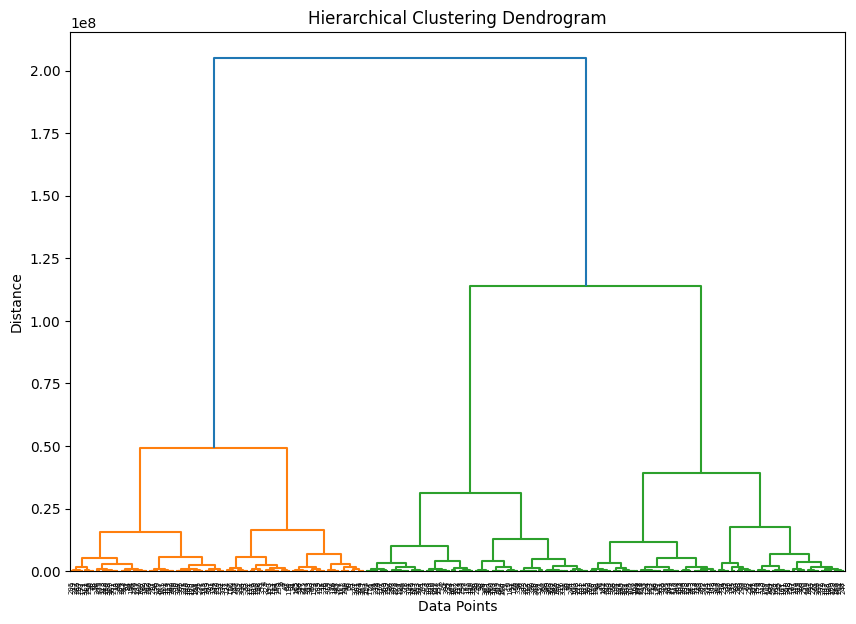

In [25]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming 'clustering_data' is your DataFrame with 'date' and 'time' features for clustering

# Calculate the linkage matrix using Ward's method (minimizes variance within clusters)
linkage_matrix = linkage(clustering_data[['date', 'time']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [36]:
import pandas as pd
# Load the updated dataset
driver_service = pd.read_csv('/Users/kashishgidwani/Downloads/updated_carpooling_dataset.csv')
driver_service.head()

,trip_id,date,time,driver_id,start_location,end_location,distance,duration,petrol_price,vehicle_mileage,weather,peak_hours,total_fare,Driver_Service,No_of_Seats,Car_Type,Driver_Wages
0,739776,18-10-2024,05:13:00,13733153,College Campus,Porur,10.5,69,89.64,18,Rainy,False,86.28,No,7,Sedan,0
1,840211,06-03-2024,12:07:10,42041085,Porur,College Campus,6.2,87,86.08,15,Sunny,False,64.04,Yes,6,SUV,6822
2,349185,10-01-2024,10:25:40,54363070,College Campus,Porur,27.3,35,92.24,17,Sunny,True,244.41,Yes,5,Hatchback,7014
3,686975,01-09-2024,11:37:00,61327131,Adyar,College Campus,17.2,35,91.11,17,Sunny,False,152.10,Yes,5,Minivan,6130
4,639235,26-07-2024,19:30:09,82493791,Velachery,College Campus,29.8,22,88.57,15,Sunny,True,316.73,Yes,4,Minivan,8448


In [41]:
# prompt: add code to convert names of all attributes inlowercase for driver_service

# Load the updated dataset
driver_service = pd.read_csv('/Users/kashishgidwani/Downloads/updated_carpooling_dataset.csv')

# Convert all column names to lowercase
driver_service.columns = driver_service.columns.str.lower()

driver_service.head()

,trip_id,date,time,driver_id,start_location,end_location,distance,duration,petrol_price,vehicle_mileage,weather,peak_hours,total_fare,driver_service,no_of_seats,car_type,driver_wages
0,739776,18-10-2024,05:13:00,13733153,College Campus,Porur,10.5,69,89.64,18,Rainy,False,86.28,No,7,Sedan,0
1,840211,06-03-2024,12:07:10,42041085,Porur,College Campus,6.2,87,86.08,15,Sunny,False,64.04,Yes,6,SUV,6822
2,349185,10-01-2024,10:25:40,54363070,College Campus,Porur,27.3,35,92.24,17,Sunny,True,244.41,Yes,5,Hatchback,7014
3,686975,01-09-2024,11:37:00,61327131,Adyar,College Campus,17.2,35,91.11,17,Sunny,False,152.10,Yes,5,Minivan,6130
4,639235,26-07-2024,19:30:09,82493791,Velachery,College Campus,29.8,22,88.57,15,Sunny,True,316.73,Yes,4,Minivan,8448


In [54]:
import pandas as pd

# Assuming 'optimized_routes_with_names_df' is your DataFrame
# and it contains a column named 'car_type' indicating the type of car (e.g., 'SUV', 'Sedan').

def adjust_capacity(row):
    if row['car_type'] == 'SUV':
        return 7
    else:
        return 5

# Apply the function to create a new column 'car_capacity'
driver_service['car_capacity'] = driver_service.apply(adjust_capacity, axis=1)

# Print the updated DataFrame to see the results
driver_service.head(10)

,trip_id,date,time,driver_id,start_location,end_location,distance,duration,petrol_price,vehicle_mileage,weather,peak_hours,total_fare,driver_service,no_of_seats,car_type,driver_wages,car_capacity
0,739776,18-10-2024,05:13:00,13733153,College Campus,Porur,10.5,69,89.64,18,Rainy,False,86.28,No,7,Sedan,0,5
1,840211,06-03-2024,12:07:10,42041085,Porur,College Campus,6.2,87,86.08,15,Sunny,False,64.04,Yes,6,SUV,6822,7
2,349185,10-01-2024,10:25:40,54363070,College Campus,Porur,27.3,35,92.24,17,Sunny,True,244.41,Yes,5,Hatchback,7014,5
3,686975,01-09-2024,11:37:00,61327131,Adyar,College Campus,17.2,35,91.11,17,Sunny,False,152.10,Yes,5,Minivan,6130,5
4,639235,26-07-2024,19:30:09,82493791,Velachery,College Campus,29.8,22,88.57,15,Sunny,True,316.73,Yes,4,Minivan,8448,5
5,269985,01-05-2024,18:04:29,61694797,Porur,College Campus,9.6,47,86.95,15,Rainy,True,91.82,Yes,5,SUV,5265,7
6,49764,20-04-2024,15:37:25,16651151,Anna Nagar,College Campus,9.5,89,85.36,18,Cloudy,False,87.85,No,4,Minivan,0,5
7,288548,16-05-2024,22:13:27,111359,Tambaram,College Campus,23.9,18,86.25,12,Sunny,False,334.97,Yes,5,Minivan,7713,5
8,147026,23-11-2024,23:54:23,48118295,College Campus,Mylapore,12.0,72,94.53,15,Cloudy,False,124.78,Yes,7,Hatchback,5365,5
9,689874,09-06-2024,21:55:50,26854888,Adyar,College Campus,27.8,44,85.87,14,Rainy,True,281.35,Yes,4,Minivan,6164,5


In [55]:
import pandas as pd

def find_nearest_passengers(driver_location, car_type):
    # Load the dataset (replace with your actual data loading)
    try:
        optimized_routes_with_names_df = pd.read_csv('/Users/kashishgidwani/Downloads/updated_carpooling_dataset.csv')
    except FileNotFoundError:
        print("Error: 'updated_carpooling_dataset.csv' not found. Please ensure the file exists in the specified location.")
        return None

    # Determine passenger capacity based on car type
    if car_type == 'SUV':
        capacity = 7
    else:
        capacity = 5

    # Check for potential location columns
    location_columns = ['start_location', 'end_location', 'passenger_location']  # Add other relevant column names

    # Find the appropriate location column
    location_col = None
    for col in location_columns:
        if col in optimized_routes_with_names_df.columns:
            location_col = col
            break

    if location_col is None:
        raise KeyError(f"None of the expected location columns ({', '.join(location_columns)}) were found in the dataset.")

    # Example: Calculate 'distance' and filter by capacity (replace with real distance)
    optimized_routes_with_names_df['distance'] = optimized_routes_with_names_df[location_col].apply(lambda x: abs(ord(x[0]) - ord(driver_location[0])))  # Use the found location column
    nearest_passengers = optimized_routes_with_names_df.nsmallest(capacity, 'distance')

    return nearest_passengers

# Get driver location and car type from user input
driver_location = input("Enter driver's location: ")
car_type = input("Enter car type (SUV or other): ")

# Find and print nearest passengers
nearest_passengers = find_nearest_passengers(driver_location, car_type)

if nearest_passengers is not None:
    print(nearest_passengers) # Print the DataFrame

    trip_id        date      time  driver_id start_location    end_location  \
7    288548  16-05-2024  22:13:27     111359       Tambaram  College Campus   
23   862505  15-06-2024  20:48:16   57331474        T Nagar  College Campus   
38   998607  03-02-2024  08:40:07   12293203       Tambaram  College Campus   
40   461936  14-12-2024  22:45:41   33633679        T Nagar  College Campus   
49   880609  08-03-2024  02:38:45   93992742        T Nagar  College Campus   

    distance  duration  petrol_price  vehicle_mileage weather  peak_hours  \
7          0        18         86.25               12   Sunny       False   
23         0        50         87.53               17   Rainy        True   
38         0        46         87.27               19   Rainy        True   
40         0        86         91.84               14  Cloudy        True   
49         0        75         86.55               19  Cloudy       False   

    total_fare Driver_Service  No_of_Seats   Car_Type  Driver_

In [53]:
import pandas as pd

# Add driver service wages (replace with your actual driver wages calculation)
driver_service_wages = 50  # Assuming a fixed wage for now

# Calculate total cost (including petrol and driver service)
optimized_routes_with_names_df['total_cost'] = optimized_routes_with_names_df['total_petrol_cost'] + driver_service_wages

# Divide the total cost among passengers (excluding driver)
num_passengers = 3  # Assuming 3 passengers, adjust as needed
optimized_routes_with_names_df['cost_per_passenger'] = optimized_routes_with_names_df['total_cost'] / num_passengers

# Print the updated DataFrame to see the results
optimized_routes_with_names_df.head(10)

,driver_id,driver_name,driver_location,passenger_name,passenger_trip_id,passenger_location,date,time,date,price,distance_km,total_liters,petrol_price,total_petrol_cost,cost_per_person,cluster_label,match,total_cost,cost_per_passenger
0,78060456,Kiaan Gala,2,Tiya Sunder,77405,College Campus,21-12-2024,17:15:52,2024-12-21,92.47,10,0.666667,92.47,61.646667,15.411667,3,1,111.646667,37.215556
1,4182471,Raunak Bedi,2,Hansh Solanki,411703,College Campus,12-03-2024,06:33:54,2024-03-12,87.36,10,0.666667,87.36,58.240000,14.560000,1,1,108.240000,36.080000
2,44830139,Nehmat Devi,2,Mishti Ranganathan,957893,College Campus,07-10-2024,11:39:51,2024-10-07,89.35,10,0.666667,89.35,59.566667,14.891667,0,1,109.566667,36.522222
3,10327139,Shlok Maharaj,2,Jhanvi Hayer,86198,College Campus,23-07-2024,10:22:38,2024-07-23,88.53,10,0.666667,88.53,59.020000,14.755000,2,1,109.020000,36.340000
4,83649499,Yasmin Krishna,3,Nitara Bhargava,787293,Mylapore,26-01-2024,15:23:53,2024-01-26,88.01,10,0.666667,88.01,58.673333,14.668333,4,0,108.673333,36.224444
5,52057659,Raunak Kothari,2,Diya Ramesh,899241,College Campus,20-01-2024,05:34:34,2024-01-20,88.29,10,0.666667,88.29,58.860000,14.715000,4,1,108.860000,36.286667
6,52057659,Raunak Kothari,2,Oorja Edwin,360156,College Campus,20-01-2024,05:34:34,2024-01-20,88.29,10,0.666667,88.29,58.860000,14.715000,4,1,108.860000,36.286667
7,25595932,Adira Deshmukh,2,Anay Sarraf,737057,College Campus,11-10-2024,23:56:39,2024-10-11,90.92,10,0.666667,90.92,60.613333,15.153333,0,1,110.613333,36.871111
8,42944315,Ela Anne,2,Lavanya Kulkarni,602130,College Campus,13-02-2024,16:49:20,2024-02-13,85.87,10,0.666667,85.87,57.246667,14.311667,4,1,107.246667,35.748889
9,29218857,Jayesh Gandhi,2,Kanav Vasa,607035,College Campus,11-06-2024,04:52:40,2024-06-11,86.84,10,0.666667,86.84,57.893333,14.473333,2,1,107.893333,35.964444


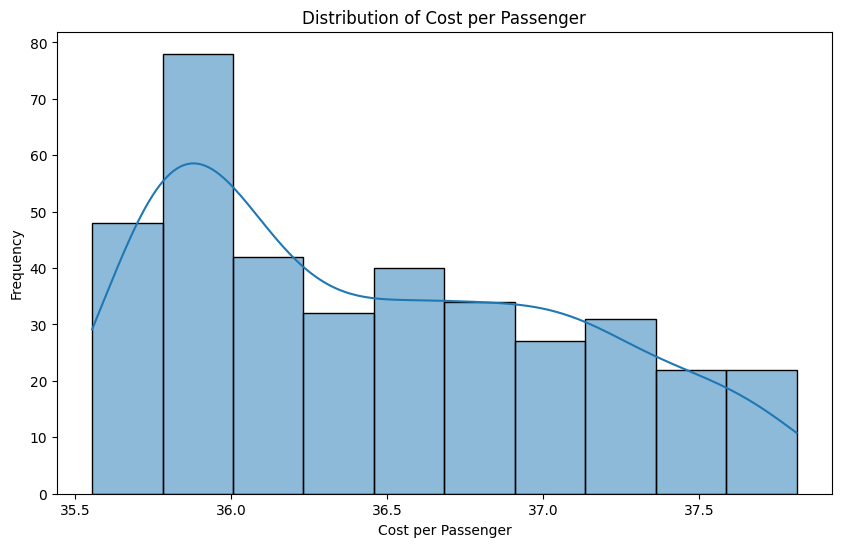

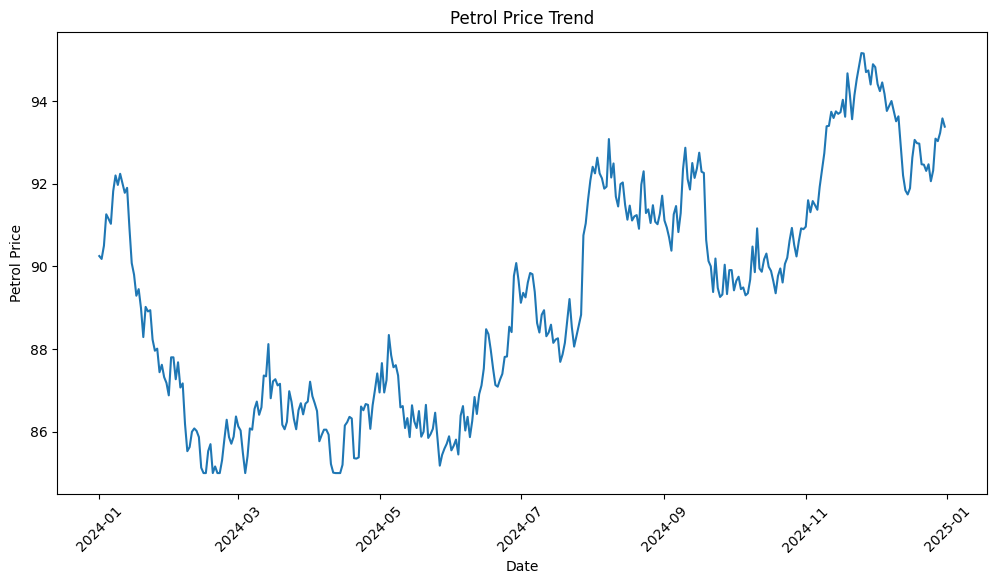

<Figure size 1000x600 with 0 Axes>

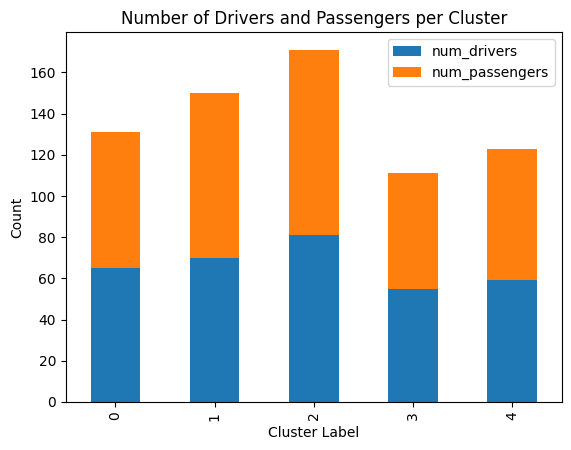

In [51]:
# Visualize the distribution of cost per passenger
plt.figure(figsize=(10, 6))
sns.histplot(optimized_routes_with_names_df['cost_per_passenger'], kde=True)
plt.title('Distribution of Cost per Passenger')
plt.xlabel('Cost per Passenger')
plt.ylabel('Frequency')
plt.show()


# Visualize the petrol price trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='petrol_price', data=petrol_prices_data)
plt.title('Petrol Price Trend')
plt.xlabel('Date')
plt.ylabel('Petrol Price')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


# Visualize the number of drivers and passengers per cluster
plt.figure(figsize=(10, 6))
cluster_summary.plot(x='cluster_label', y=['num_drivers', 'num_passengers'], kind='bar', stacked=True)
plt.title('Number of Drivers and Passengers per Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

In [59]:
print(optimized_routes_with_names_df.columns)


Index(['driver_id', 'driver_name', 'driver_location', 'passenger_name',
       'passenger_trip_id', 'passenger_location', 'date', 'time', 'date',
       'price', 'distance_km', 'total_liters', 'petrol_price',
       'total_petrol_cost', 'cost_per_person', 'cluster_label', 'match',
       'total_cost', 'cost_per_passenger', 'fuel_efficiency_percentage'],
      dtype='object')


In [62]:
# Assuming total_cost and cost_per_passenger are related
optimized_routes_with_names_df['num_passengers'] = (
    optimized_routes_with_names_df['total_cost'] / optimized_routes_with_names_df['cost_per_passenger']
)


In [63]:
# Calculate fuel consumption per passenger
optimized_routes_with_names_df['fuel_consumption_per_passenger'] = (
    optimized_routes_with_names_df['distance_km'] / optimized_routes_with_names_df['num_passengers']
)

# Calculate fuel cost per passenger
optimized_routes_with_names_df['fuel_cost_per_passenger'] = (
    optimized_routes_with_names_df['fuel_consumption_per_passenger'] * optimized_routes_with_names_df['petrol_price']
)

# Calculate individual travel fuel cost (assuming each person drives alone)
optimized_routes_with_names_df['individual_fuel_cost'] = (
    optimized_routes_with_names_df['distance_km'] * optimized_routes_with_names_df['petrol_price']
)

# Calculate fuel efficiency percentage
optimized_routes_with_names_df['fuel_efficiency_percentage'] = (
    (1 - (optimized_routes_with_names_df['fuel_cost_per_passenger'] / optimized_routes_with_names_df['individual_fuel_cost'])) * 100
)

# Handle potential division by zero
optimized_routes_with_names_df['fuel_efficiency_percentage'] = optimized_routes_with_names_df['fuel_efficiency_percentage'].fillna(0)

# Display the updated DataFrame
print(optimized_routes_with_names_df[['distance_km', 'petrol_price', 'num_passengers', 
                                      'fuel_consumption_per_passenger', 'fuel_cost_per_passenger', 
                                      'individual_fuel_cost', 'fuel_efficiency_percentage']].head())


   distance_km  petrol_price  num_passengers  fuel_consumption_per_passenger  \
0           10         92.47             3.0                        3.333333   
1           10         87.36             3.0                        3.333333   
2           10         89.35             3.0                        3.333333   
3           10         88.53             3.0                        3.333333   
4           10         88.01             3.0                        3.333333   

   fuel_cost_per_passenger  individual_fuel_cost  fuel_efficiency_percentage  
0               308.233333                 924.7                   66.666667  
1               291.200000                 873.6                   66.666667  
2               297.833333                 893.5                   66.666667  
3               295.100000                 885.3                   66.666667  
4               293.366667                 880.1                   66.666667  


In [64]:
import pandas as pd
import numpy as np

def calculate_additional_fuel_consumption(df):
    """
    Calculates the additional fuel consumed by students without cars using other means of transport.
    Assumes 'fuel_efficiency_other_transport' is defined (e.g., km/liter for bus/train).

    Args:
        df: Pandas DataFrame with relevant data.

    Returns:
        Pandas Series with the additional fuel consumption per student without a car.
    """

    # Check for required columns
    required_cols = ['distance_km', 'car_available', 'fuel_efficiency_other_transport']
    if not all(col in df.columns for col in required_cols):
      raise ValueError(f"DataFrame is missing required columns: {', '.join(required_cols)}")

    # Calculate additional fuel consumption for students without cars.
    # We assume that distance is the same for those with and without a car.
    df['additional_fuel'] = 0
    df.loc[~df['car_available'], 'additional_fuel'] = (df.loc[~df['car_available'], 'distance_km'] / df['fuel_efficiency_other_transport'])


    return df['additional_fuel']


# Example Usage (replace with your actual DataFrame and column names):
# Sample DataFrame (replace with your actual data)
data = {'distance_km': [10, 20, 15, 25, 12],
        'car_available': [True, False, True, False, True],
        'fuel_efficiency_other_transport': [10, 12, 10, 12, 10]} #Example fuel efficiency for other transport

optimized_routes_with_names_df = pd.DataFrame(data)


additional_fuel = calculate_additional_fuel_consumption(optimized_routes_with_names_df)

print(optimized_routes_with_names_df)
print("\nAdditional Fuel Consumption (liters):\n", additional_fuel)


   distance_km  car_available  fuel_efficiency_other_transport  \
0           10           True                               10   
1           20          False                               12   
2           15           True                               10   
3           25          False                               12   
4           12           True                               10   

   additional_fuel  
0         0.000000  
1         1.666667  
2         0.000000  
3         2.083333  
4         0.000000  

Additional Fuel Consumption (liters):
 0    0.000000
1    1.666667
2    0.000000
3    2.083333
4    0.000000
Name: additional_fuel, dtype: float64


/var/folders/l9/1shy83z97bg4vkm0xps3hmnw0000gn/T/ipykernel_4228/1760504514.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.66666667 2.08333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[~df['car_available'], 'additional_fuel'] = (df.loc[~df['car_available'], 'distance_km'] / df['fuel_efficiency_other_transport'])
